# Benchmarking the Pfaffian strategies

This notebook benchmarks the available Pfaffian strategies in terms of **time** and **memory** for both the **forward** and **backward** passes.

Four strategies are compared:

- `PfaffianFDBPf`: computes the Pfaffian from `sqrt(|det(A)|)` with a custom **analytic** backward. Valid for any skew-symmetric matrix.
- `PfaffianBlockDet`: computes the Pfaffian from the determinant of the upper-right block, with a custom analytic backward.
- `PfaffianDet`: a reference baseline that also computes `pf = sqrt(|det(A)|)` but differentiates straight through `det`/`sqrt` with **plain autograd** (no custom backward), to expose the cost of naive autodiff against the analytic backward of `PfaffianFDBPf`.
- `PfaffianParlettReid`: computes the **signed** Pfaffian via batched Parlett-Reid skew-tridiagonalization, with a custom analytic backward. Valid for any skew-symmetric matrix.

Each strategy is invoked through `Strategy.apply(matrix)`.

For each strategy and matrix size we report, **averaged over 20 random seeds with 95% confidence intervals**:

- the median forward time,
- the median backward time,
- the forward peak memory,
- the forward + backward peak memory.

## Validity note

`PfaffianBlockDet`'s forward only returns the *true* Pfaffian for **block-antidiagonal** skew matrices of the form

$$ A = \begin{pmatrix} 0 & B \\ -B^{T} & 0 \end{pmatrix}. $$

To keep the comparison both **fair** and **numerically valid**, we benchmark *all* strategies on block-antidiagonal inputs. `PfaffianFDBPf` and `PfaffianDet` are valid on any skew matrix (including this form), so this input shape is a common ground on which all strategies compute the same quantity.

In [1]:
import os
import sys

# The helper module lives next to this notebook; ensure it is importable both when
# running the notebook directly and when it is executed during the Sphinx docs build.
sys.path.insert(0, os.getcwd())

import torch
from _strategies_benchmark_helpers import benchmark_strategies, plot_results

from torch_pfaffian.strategies.pfaffian_block_det import PfaffianBlockDet
from torch_pfaffian.strategies.pfaffian_det import PfaffianDet
from torch_pfaffian.strategies.pfaffian_fdbpf import PfaffianFDBPf
from torch_pfaffian.strategies.pfaffian_parlett_reid import PfaffianParlettReid

strategies = [PfaffianFDBPf, PfaffianBlockDet, PfaffianDet, PfaffianParlettReid]

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running benchmarks on device: {device}")

Running benchmarks on device: cpu


## Running the benchmark

The benchmarking and plotting logic lives in `_strategies_benchmark_helpers.py` to keep this notebook focused on the narrative. `benchmark_strategies` sweeps the matrix dimension `2n` and, for every strategy, measures each metric once per seed across `n_seeds` seeds, returning the across-seed mean and the half-width of the 95% confidence interval.

In [2]:
sizes_n = [2, 4, 8, 16, 32]
batch_size = 16
n_seeds = 20

results = benchmark_strategies(strategies, sizes_n, batch_size, device=device, n_seeds=n_seeds)
results

/home/local/USHERBROOKE/ginj2102/github/TorchPfaffian/.venv/lib/python3.14/site-packages/torch/profiler/profiler.py:217: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


{'PfaffianFDBPf': {'dimension': [4, 8, 16, 32, 64],
  'forward_time_mean': [8.19441003841348e-05,
   8.427420107182115e-05,
   0.0016809296004794306,
   0.0010581897498923355,
   0.005361456051832647],
  'backward_time_mean': [0.00023227104975376278,
   0.002127916499011917,
   0.0017952793492440832,
   0.0031126482488616604,
   0.012903559449114255],
  'forward_memory_mean': [5578.4, 13611.6, 41978.0, 147905.2, 555889.6],
  'forward_backward_memory_mean': [51983.55,
   191691.65,
   741398.7,
   2922157.3,
   11608700.75],
  'forward_time_ci': [8.464542021427269e-06,
   2.245680630823186e-06,
   0.0011291846833554554,
   0.0009377027147125496,
   0.0025269452616774653],
  'backward_time_ci': [1.4114582596917043e-05,
   0.0011233393513818512,
   0.0009505318621660702,
   0.0005768491523161676,
   0.002477009668380689],
  'forward_memory_ci': [22.753778892630926,
   25.03830604662005,
   31.004671159104564,
   28.73910075874074,
   798.6774049370949],
  'forward_backward_memory_ci': [31

## Results

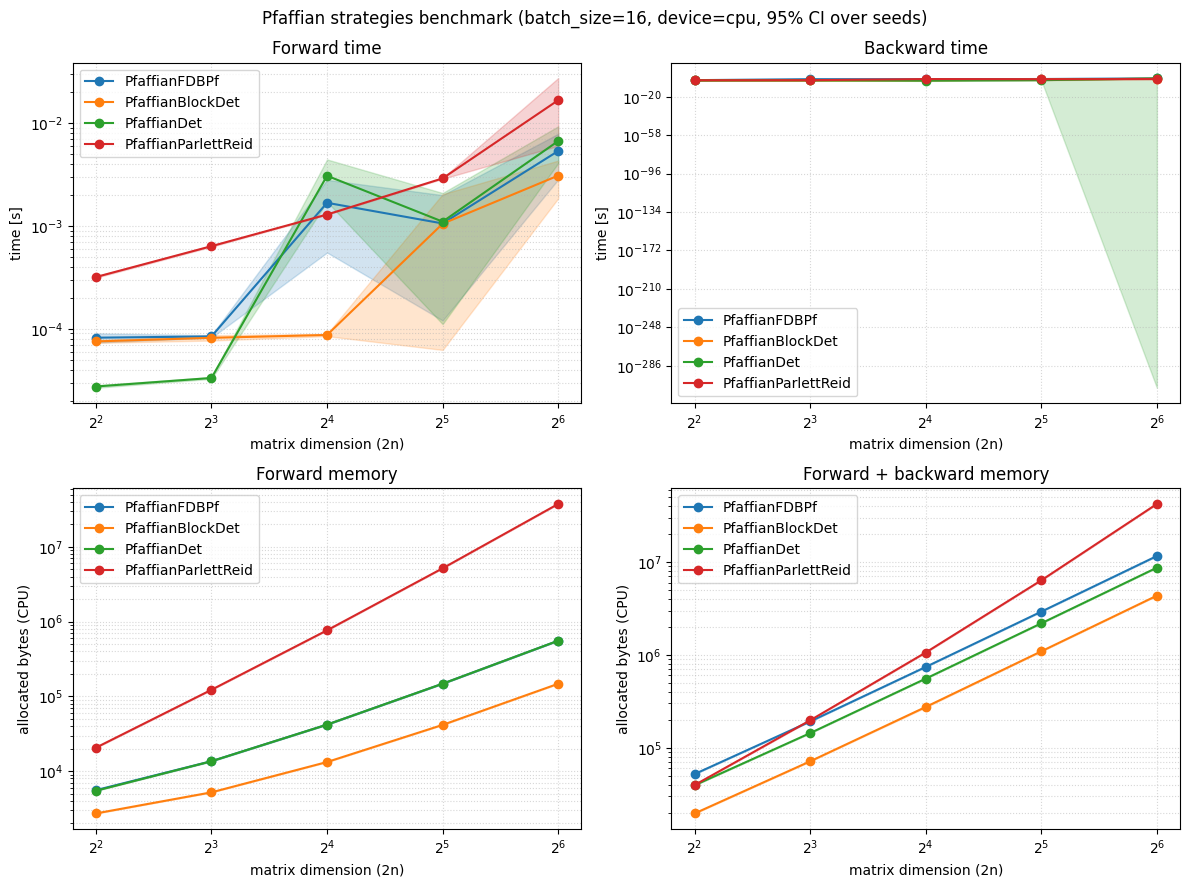

In [3]:
fig = plot_results(results, strategies, batch_size, device=device)

## Conclusions and caveats

The figure above reports, as a function of the matrix dimension $2n$, the median forward time, the median backward time, the forward peak memory, and the combined forward + backward peak memory for every strategy, evaluated on block-antidiagonal skew matrices. Shaded bands are 95% confidence intervals over the 20 seeds (they are essentially invisible for memory, which is seed-independent for a fixed shape).

**Memory-metric caveat.** The memory numbers depend on the device:

- On **CUDA**, the reported value is a true peak obtained from `torch.cuda.reset_peak_memory_stats()` / `torch.cuda.max_memory_allocated()`.
- On **CPU** (the continuous-integration case), no equivalent peak counter exists, so we report the **allocated bytes** measured by `torch.profiler` instead. This is an aggregate of allocations rather than a strict instantaneous peak, so CPU and CUDA memory values are not directly comparable and the absolute CPU numbers should be read as a relative indicator across strategies and sizes.

`PfaffianFDBPf` and `PfaffianDet` share the same forward (`sqrt(|det(A)|)`); their difference is the backward, so the backward panels highlight the analytic custom backward against plain autograd.